# Dataset: Landmark Recognition Dataset

## Classes: 10
## Images per class: 50
## Total images: 500

### Image size: 224x224

In [1]:
import os
import matplotlib.pyplot as plt
import cv2

In [2]:
os.chdir("..")

## Dataset

In [4]:
classes = os.listdir(PATH)
classes

['Big_Ben',
 'Christ_The_Redeemer',
 'Colloseum',
 'Eiffel_Tower',
 'Leaning_Tower_Of_Pisa',
 'Mount_Fuji',
 'Pyramids_Of_Giza',
 'Saint_Basil_Cathedral',
 'Sydney_Opera_House',
 'Taj_Mahal']

In [3]:
total_elements = 0
PATH = "data/dataset"
total_folders = len(os.listdir(PATH))

for folder in os.listdir(PATH):
    print(f"folder: {folder}, num_elements: {len(os.listdir(f"{PATH}/{folder}"))}")
    total_elements += len(os.listdir(f"{PATH}/{folder}"))

print(f"\nTotal Folders: {total_folders}")
print(f"Total Elements: {total_elements}")

folder: Big_Ben, num_elements: 50
folder: Christ_The_Redeemer, num_elements: 50
folder: Colloseum, num_elements: 50
folder: Eiffel_Tower, num_elements: 50
folder: Leaning_Tower_Of_Pisa, num_elements: 50
folder: Mount_Fuji, num_elements: 50
folder: Pyramids_Of_Giza, num_elements: 50
folder: Saint_Basil_Cathedral, num_elements: 50
folder: Sydney_Opera_House, num_elements: 50
folder: Taj_Mahal, num_elements: 50

Total Folders: 10
Total Elements: 500


In [29]:
def show_images(class_name, n=5):
    path = f"{PATH}/{class_name}"
    images = os.listdir(path)

    plt.figure(figsize=(10,3))

    for i in range(n):
        img_src = os.path.join(PATH, class_name, images[i])
        img = cv2.imread(img_src)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

## Images Example

Christ The Redeemer

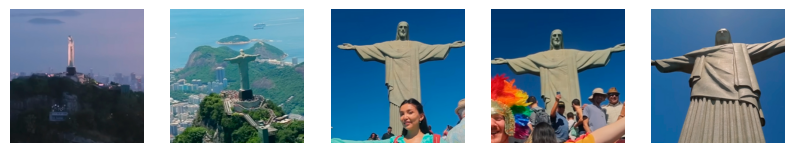

In [30]:
show_images("Christ_The_Redeemer")

Saint Basil Cathedral

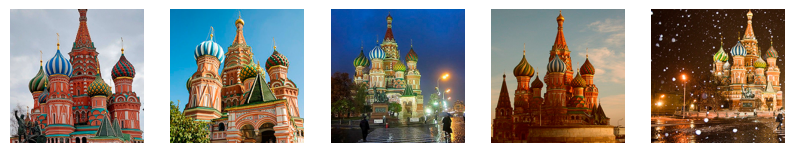

In [31]:
show_images("Saint_Basil_Cathedral")

Leaning Tower Of Pisa

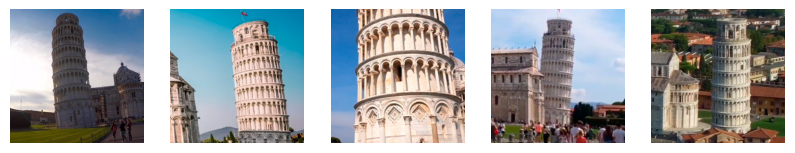

In [32]:
show_images("Leaning_Tower_Of_Pisa")

Checking the dimensions

In [42]:
sizes = []

for c in classes:
    path = f"{PATH}/{c}"
    for img_name in os.listdir(path):
        img_src = os.path.join(PATH, c, img_name)
        img = cv2.imread(img_src)
        sizes.append(img.shape)

set(sizes)

{(224, 224, 3)}

## Data Augmentation example

In [57]:
import numpy as np


def augment_image(img):

    h, w = img.shape[:2]

    # Horizontal flip
    flip = cv2.flip(img, 1)

    # Rotation
    angle = np.random.uniform(-15, 15)
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    rotation = cv2.warpAffine(img, M, (w, h))
    rotate_crop = rotation[25:h-25, 25:w-25]
    rotate_img = cv2.resize(rotate_crop, (w, h))

    # Brightness
    brightness = cv2.convertScaleAbs(img, alpha=1, beta=40)

    # Contrast
    contrast = cv2.convertScaleAbs(img, alpha=1.5, beta=0)

    # Zoom
    crop = img[40:h-40, 40:w-40]
    zoom = cv2.resize(crop, (w, h))

    return [img, flip, rotate_img, brightness, contrast, zoom]

In [70]:
def show_augmentations(img_path):
    print(img_path)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    images = augment_image(img)

    titles = [
        "Original",
        "Horizontal Flip",
        "Rotation",
        "Brightness",
        "Contrast",
        "Zoom"
    ]

    plt.figure(figsize=(12,4))

    for i in range(len(images)):
        plt.subplot(1,6,i+1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis("off")

    plt.show()

Christ The Redeemer 2nd photo

data/dataset/Christ_The_Redeemer/Christ_The_Redeemer_2.jpg


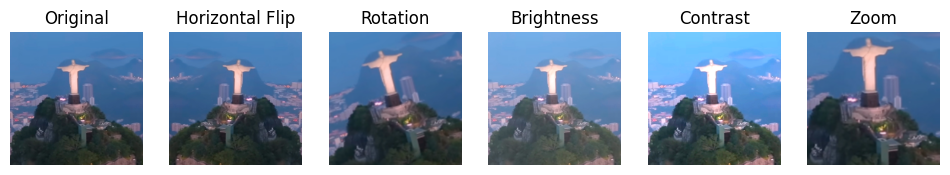

In [71]:
show_augmentations(f"{PATH}/Christ_The_Redeemer/Christ_The_Redeemer_2.jpg")

Saint Basil Cathedral 1st photo

data/dataset/Saint_Basil_Cathedral/Saint Basil_Cathedral_1.jpg


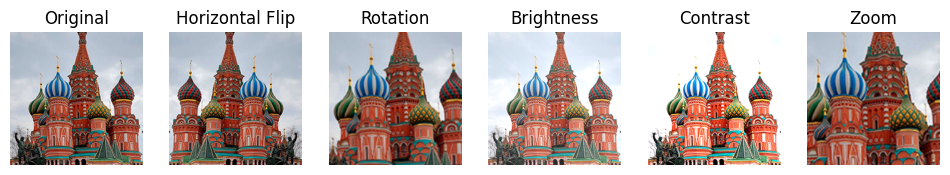

In [78]:
show_augmentations(f"{PATH}/Saint_Basil_Cathedral/Saint Basil_Cathedral_1.jpg")

Leaning Tower Of Pisa 1st photo

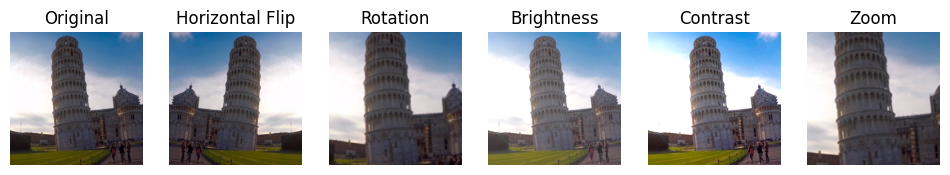

In [59]:
show_augmentations(f"{PATH}/Leaning_Tower_Of_Pisa/Leaning_Tower_Of_Pisa_1.jpg")